<h1>Attention is All You Need</h1>

<h6>In this notebook, we will implement the Transformer model from scratch.</h6>
<h6><b>Note:</b> For Testing ,Test cases are written by the AI </h6>

<h2>Scaled Dot Product Attention</h2>

In [ ]:
import torch 
import math
import torch.nn.functional as F
import torch.nn as nn

def scaled_dot_product(q , k, v,mask=None,dropout=None):
    d_k=q.size(-1)
    score=torch.matmul(q,k.transpose(-2,-1))/math.sqrt(d_k)
    if mask is not None:
        score=score.masked_fill(mask==0,float('-inf'))
    attn=F.softmax(score,dim=-1)
    if dropout is not None:
        attn=dropout(attn)
    out=torch.matmul(attn,v)
    return  out,attn

# Test the function
q = torch.rand(1, 4, 8)  
k = torch.rand(1, 4, 8)
v = torch.rand(1, 4, 8)

out, attn = scaled_dot_product(q, k, v)
print(out.shape)  
print(attn.shape)   
print(attn.sum(dim=-1)) 
    

torch.Size([1, 4, 8])
torch.Size([1, 4, 4])
tensor([[1., 1., 1., 1.]])


<h2>Multi Head Attention Mechanism</h2>

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self,d_model:int,num_heads:int,dropout: float=0.1):
        super().__init__()
        assert d_model%num_heads==0,"model dimension dhould be divisible by the heads"
        self.d_model=d_model
        self.num_heads=num_heads
        self.d_k=d_model//num_heads
        self.w_k=nn.Linear(d_model,d_model)
        self.w_q=nn.Linear(d_model,d_model)
        self.w_v=nn.Linear(d_model,d_model)
        self.w_O=nn.Linear(d_model,d_model)
        self.dropout=nn.Dropout(dropout)
        self.attn_weight=None
    def split_heads(self,x:torch.Tensor)->torch.Tensor:
        batch,seq_length,_=x.shape
        x=x.view(batch,seq_length,self.num_heads, self.d_k)
        return x.transpose(1,2)
    def combine_heads(self, x: torch.Tensor) -> torch.Tensor:
        batch, _, seq_len, _ = x.shape
        x = x.transpose(1, 2).contiguous()
        return x.view(batch, seq_len, self.d_model)
    def forward(self,query,key,value,mask=None):
        q=self.split_heads(self.w_q(query))
        k=self.split_heads(self.w_k(key))
        v=self.split_heads(self.w_v(value))
        if mask is not None  and mask.dim()==3:
            mask.unsqueeze(1)
        out,attn=scaled_dot_product(q,k,v,mask,self.dropout)
        self.attn_weight=attn.detach()
        out=self.combine_heads(out)
        return self.w_O(out)


# Test the MultiHeadAttention class

mha = MultiHeadAttention(d_model=64, num_heads=8)
x = torch.rand(2, 10, 64)  
out = mha(x, x, x)
print(out.shape)              
print(mha.attn_weight.shape)

torch.Size([2, 10, 64])
torch.Size([2, 8, 10, 10])


<h2>Positional Encoding </h2>

torch.Size([2, 10, 64])


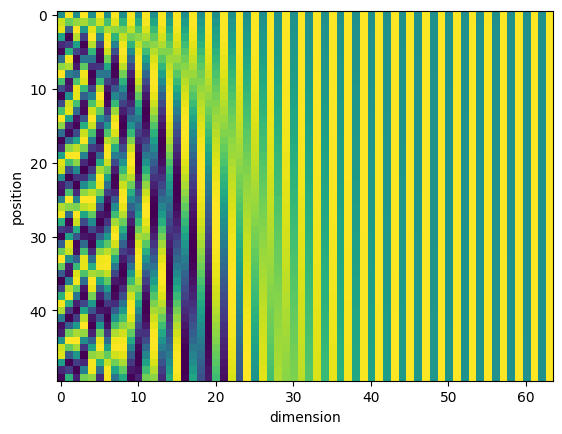

In [ ]:
class PositionalEncoding(nn.Module):
     def __init__(self, d_model: int,max_len: int = 5000,dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1) 
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)  
        pe[:, 1::2] = torch.cos(position * div_term)  
        pe = pe.unsqueeze(0)  
        self.register_buffer("pe", pe)
     def forward(self,x:torch.tensor)->torch.tensor:
        x=x+self.pe[:,:x.size(1)]
        return self.dropout(x)


# Test the PositionalEncoding class
pe_layer = PositionalEncoding(d_model=64, max_len=100)
x = torch.zeros(2, 10, 64)  # batch=2, seq_len=10, d_model=64
out = pe_layer(x)
print(out.shape)  # should be (2, 10, 64) -- unchanged shape

import matplotlib.pyplot as plt
plt.imshow(pe_layer.pe[0, :50, :].numpy(), aspect='auto')
plt.xlabel("dimension"); plt.ylabel("position")
plt.show()  # should look like smooth wave-like stripes, not noise

<h2>Position Wise feedforward Network</h2>

In [ ]:
class PositionWiseFeedForwardNetwork(nn.Module):
    def __init__(self,d_model:int,d_ff:int,dropout:float=0.1):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(d_model,d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff,d_model),
        )
    def forward(self,x):
        return self.net(x)
# Test the PositionWiseFeedForwardNetwork class
ffn = PositionWiseFeedForwardNetwork(d_model=64, d_ff=256)
x = torch.rand(2, 10, 64)
out = ffn(x)
print(out.shape)  # should be (2, 10, 64) -- same as input, d_ff is just an internal expansion

torch.Size([2, 10, 64])


<h2>Encoder layer </h2>

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self,d_model,num_head,d_ff,dropout=0.1):
        super().__init__()
        self.self_attn=MultiHeadAttention(d_model,num_head,dropout)
        self.ffn=PositionWiseFeedForwardNetwork(d_model,d_ff,dropout)
        self.norm1=nn.LayerNorm(d_model)
        self.norm2=nn.LayerNorm(d_model)
        self.dropout1=nn.Dropout(dropout)
        self.dropout2=nn.Dropout(dropout)
    def forward(self, x, mask=None):
        attn_out = self.self_attn(x,x,x, mask)
        x=self.norm1(x+self.dropout1(attn_out))
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))
        return x

# Test the EncoderLayer class
layer = EncoderLayer(d_model=64, num_head=8, d_ff=256)
x = torch.rand(2, 10, 64)
out = layer(x)
print(out.shape)  
        

torch.Size([2, 10, 64])


In [ ]:
class Encoder(nn.Module):
    def __init__(self,vocab_size,d_model,num_heads,d_ff,num_layers,max_len=5000,dropout=0.1):
        super().__init__()
        self.d_model=d_model
        self.embed=nn.Embedding(vocab_size, d_model)
        self.pos_enc=PositionalEncoding(d_model,max_len,dropout)
        self.layers=nn.ModuleList([EncoderLayer(d_model,num_heads,d_ff,dropout)for _ in range(num_layers)])
        self.norm = nn.LayerNorm(d_model)
    def forward(self,src,src_mask=None):
        x=self.embed(src)*math.sqrt(self.d_model)
        x=self.pos_enc(x)
        for layer in self.layers:
            x = layer(x,src_mask)
        return self.norm(x)

# Test the Encoder class
enc = Encoder(vocab_size=100, d_model=64, num_heads=8, d_ff=256, num_layers=6)
src = torch.randint(0, 100, (2, 10))  
out = enc(src)
print(out.shape) 

torch.Size([2, 10, 64])


<h2>Decoder Layer</h2>

In [ ]:
import torch.nn as nn


class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = PositionWiseFeedForwardNetwork(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        attn_out = self.self_attn(x, x, x, tgt_mask)          # masked self-attention
        x = self.norm1(x + self.dropout1(attn_out))

        cross_out = self.cross_attn(x, enc_out, enc_out, src_mask)  # query=decoder, key/value=encoder
        x = self.norm2(x + self.dropout2(cross_out))

        ffn_out = self.ffn(x)
        x = self.norm3(x + self.dropout3(ffn_out))
        return x

# Test the DecoderLayer class
dec_layer = DecoderLayer(d_model=64, num_heads=8, d_ff=256)
x = torch.rand(2, 10, 64)       # decoder input, seq_len=10
enc_out = torch.rand(2, 12, 64) # encoder output, seq_len=12 (can differ from decoder's!)
out = dec_layer(x, enc_out)
print(out.shape)  # should be (2, 10, 64) -- matches decoder's seq_len, NOT encoder's

torch.Size([2, 10, 64])


In [ ]:
class Decoder(nn.Module):
    def __init__(self, vocab_size,d_model,num_head, d_ff,num_layers,max_len=5000,dropout=0.1):
        super().__init__()
        self.d_model=d_model
        self.embed=nn.Embedding(vocab_size,d_model)
        self.pos_enc=PositionalEncoding(d_model,max_len,dropout)
        self.layers = nn.ModuleList([DecoderLayer(d_model, num_head, d_ff, dropout) for _ in range(num_layers)])
        self.norm = nn.LayerNorm(d_model)
    def forward(self,tgt,enc_out,src_mask=None,tgt_mask=None):
        x=self.embed(tgt)*math.sqrt(self.d_model)
        x=self.pos_enc(x)
        for layer in self.layers:
            x=layer(x,enc_out,src_mask,tgt_mask)
        return self.norm(x)
# Test the Decoder class
dec = Decoder(vocab_size=100, d_model=64, num_head=8, d_ff=256, num_layers=6)
tgt = torch.randint(0, 100, (2, 9))     
enc_out = torch.rand(2, 12, 64)         
out = dec(tgt, enc_out)
print(out.shape)  # should be (2, 9, 64) -- follows target's seq_len

torch.Size([2, 9, 64])


<h2>Transformer Noe</h2>

In [35]:
class Transformer(nn.Module):
    def __init__(self,src_vocab_size,tgt_vocab_size,d_model=512,num_head=8,d_ff=2048,num_layers=6,max_len=5000,dropout=0.1,pad_idx=0,):
        super().__init__()
        self.pad_idx=pad_idx 
        self.encoder=Encoder(src_vocab_size, d_model, num_head, d_ff, num_layers, max_len, dropout)
        self.decoder=Decoder(tgt_vocab_size, d_model, num_head, d_ff, num_layers, max_len, dropout)
        self.generator = nn.Linear(d_model, tgt_vocab_size)
        for p in self.parameters():
            if p.dim()>1:
                nn.init.xavier_uniform_(p)
    def make_src_mask(self, src):
        return (src!=self.pad_idx).unsqueeze(1).unsqueeze(2)
    def make_tgt_mask(self, tgt):
        batch, seq_len = tgt.shape
        pad_mask=(tgt != self.pad_idx).unsqueeze(1).unsqueeze(2) 
        look_ahead=torch.tril(torch.ones(seq_len,seq_len,device=tgt.device)).bool()
        return pad_mask & look_ahead
    def forward(self, src, tgt):
        src_mask=self.make_src_mask(src)
        tgt_mask=self.make_tgt_mask(tgt)
        enc_out=self.encoder(src,src_mask)
        dec_out=self.decoder(tgt,enc_out,src_mask,tgt_mask)
        return self.generator(dec_out)

In [ ]:
# Test the Transformer class
model = Transformer(src_vocab_size=100, tgt_vocab_size=100, d_model=64, num_head=8, d_ff=256, num_layers=2)

# 1. test masks in isolation first
src = torch.tensor([[5, 8, 3, 0, 0]])   # last two tokens are padding (pad_idx=0)
tgt = torch.tensor([[5, 8, 3, 9, 0]])

src_mask = model.make_src_mask(src)
print(src_mask.shape)  # (1, 1, 1, 5)
print(src_mask)        # last two positions should be False

tgt_mask = model.make_tgt_mask(tgt)
print(tgt_mask.shape)  # (1, 1, 5, 5)
print(tgt_mask[0, 0])  # should look lower-triangular, with last column also False (padding)

# 2. then test the full forward pass
out = model(src, tgt)
print(out.shape)  # should be (1, 5, 100) -- (batch, seq_len, vocab_size)

torch.Size([1, 1, 1, 5])
tensor([[[[ True,  True,  True, False, False]]]])
torch.Size([1, 1, 5, 5])
tensor([[ True, False, False, False, False],
        [ True,  True, False, False, False],
        [ True,  True,  True, False, False],
        [ True,  True,  True,  True, False],
        [ True,  True,  True,  True, False]])
torch.Size([1, 5, 100])


In [39]:
class NoamScheduler:
    """lr = d_model^-0.5 * min(step^-0.5, step * warmup_steps^-1.5)"""
    def __init__(self,optimizer,d_model,warmup_steps=4000):
        self.optimizer=optimizer
        self.d_model=d_model
        self.warmup_steps=warmup_steps
        self.step_num=0
 
    def step(self):
        self.step_num += 1
        lr=(self.d_model**-0.5)* min(
            self.step_num**-0.5,self.step_num *self.warmup_steps**-1.5
        )
        for group in self.optimizer.param_groups:
            group["lr"]=lr
        self.optimizer.step()

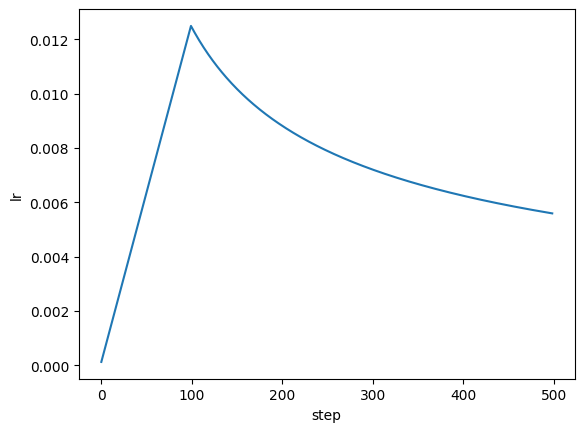

In [ ]:
# Test the NoamScheduler class
import torch

dummy_param = torch.nn.Parameter(torch.rand(1))
opt = torch.optim.Adam([dummy_param], lr=0)
sched = NoamScheduler(opt,d_model=64, warmup_steps=100)

lrs = []
for step in range(1, 500):
    sched.step()
    lrs.append(opt.param_groups[0]["lr"])

import matplotlib.pyplot as plt
plt.plot(lrs)
plt.xlabel("step"); plt.ylabel("lr")
plt.show()

<h1>From here Training and Testing puerly written by ai </h1>

In [45]:
def toy_training_run():
    torch.manual_seed(0)
 
    VOCAB_SIZE = 20      # tokens 0..19; we'll treat 0 as PAD, 1 as BOS, 2 as EOS
    PAD, BOS, EOS = 0, 1, 2
    SEQ_LEN = 8
    BATCH_SIZE = 32
    NUM_BATCHES = 600
 
    model = Transformer(
        src_vocab_size=VOCAB_SIZE,
        tgt_vocab_size=VOCAB_SIZE,
        d_model=64,
        num_head=4,
        d_ff=128,
        num_layers=2,
        max_len=50,
        dropout=0.1,
        pad_idx=PAD,
    )
 
    optimizer = torch.optim.Adam(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9)
    scheduler = NoamScheduler(optimizer, d_model=64, warmup_steps=100)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD)
 
    def make_batch():
        # random sequences using tokens [3..VOCAB_SIZE-1] so they don't collide with PAD/BOS/EOS
        src = torch.randint(3, VOCAB_SIZE, (BATCH_SIZE, SEQ_LEN))
        reversed_seq = src.flip(dims=[1])
 
        # decoder input: <BOS> + reversed[:-1]   (teacher forcing, shifted right)
        tgt_in = torch.cat([torch.full((BATCH_SIZE, 1), BOS), reversed_seq[:, :-1]], dim=1)
        # decoder target: reversed + <EOS>
        tgt_out = torch.cat([reversed_seq, torch.full((BATCH_SIZE, 1), EOS)], dim=1)
        tgt_in = torch.cat([tgt_in, torch.full((BATCH_SIZE, 1), EOS)], dim=1)  # keep shapes aligned
        return src, tgt_in[:, :SEQ_LEN + 1], tgt_out
 
    model.train()
    for step in range(1, NUM_BATCHES + 1):
        src, tgt_in, tgt_out = make_batch()
 
        logits = model(src, tgt_in)  # (batch, seq_len+1, vocab)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), tgt_out.reshape(-1))
 
        optimizer.zero_grad()
        loss.backward()
        scheduler.step()
 
        if step % 50 == 0 or step == 1:
            print(f"step {step:4d} | loss {loss.item():.4f} | lr {optimizer.param_groups[0]['lr']:.6f}")
 
    print("\nFinal check -- does it actually reverse a sequence?")
    model.eval()
    with torch.no_grad():
        src, tgt_in, tgt_out = make_batch()
        logits = model(src, tgt_in)
        preds = logits.argmax(dim=-1)
        print("input   :", src[0].tolist())
        print("target  :", tgt_out[0].tolist())
        print("predict :", preds[0].tolist())
 
 
if __name__ == "__main__":
    toy_training_run()

step    1 | loss 3.5416 | lr 0.000125
step   50 | loss 2.0410 | lr 0.006250
step  100 | loss 1.9123 | lr 0.012500
step  150 | loss 1.7651 | lr 0.010206
step  200 | loss 1.4804 | lr 0.008839
step  250 | loss 1.3407 | lr 0.007906
step  300 | loss 1.1808 | lr 0.007217
step  350 | loss 1.0320 | lr 0.006682
step  400 | loss 1.0130 | lr 0.006250
step  450 | loss 0.8121 | lr 0.005893
step  500 | loss 0.7373 | lr 0.005590
step  550 | loss 0.7084 | lr 0.005330
step  600 | loss 0.6992 | lr 0.005103

Final check -- does it actually reverse a sequence?
input   : [15, 19, 3, 17, 14, 5, 3, 9]
target  : [9, 3, 5, 14, 17, 3, 19, 15, 2]
predict : [9, 3, 5, 14, 17, 3, 15, 15, 2]
